#📌 Extracción

In [1]:
# importamos bibliotecas a utilizar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
# cargamos los datos, convirtiendolo en un dataframe
datos = pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')

# primer vistazo a los datos
datos.head(2)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


Las columnas anidadas son:

|Customer|Phone|Internet |Account|
| ------------- |:-------------:| ------------- |:-------------:|
|Gender|Phone|Internet Service|Contract|
|Senior Citizen| Multiple Lines|Online Security|Paperless Billing|
|Partner| |Online Backup|Payment Method|
|Dependents| |Device Protection|Charges Monthly|
|Tenure| |Tech Support|Charges Total|
|||Streaming TV||
|||Streaming Movies||

In [5]:
# normalizamos en cada caso correspondiente y guardamos los datos en una variable distinta
df_customerID = pd.DataFrame(datos['customerID'])
df_churn = pd.DataFrame(datos['Churn'])
df_customer = pd.json_normalize(datos['customer'])
df_phone = pd.json_normalize(datos['phone'])
df_internet = pd.json_normalize(datos['internet'])
df_account = pd.json_normalize(datos['account'])

# concatenamos las columnas
datos = pd.concat([df_customerID, df_churn, df_customer, df_phone, df_internet, df_account], axis=1)

# establecemos la opción de ver todas las columnas
pd.set_option('display.max_columns', None)

# segundo vistazo a los datos
datos.head(1)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3


In [6]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


#🔧 Transformación

In [7]:
# exploramos las columnas del dataset y verificamos sus tipos de datos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


## Comprobación de incoherencias en los datos y manejos de inconsistencias

Verificamos si hay valores ausentes, en blanco, duplicados, errores de formato e inconsistencias en las categorías.

In [8]:
# averiguamos los valores unicos por cada columna
for x in datos.columns:
  if datos[x].nunique() < 20:
    print(f'La columna {datos[x].name} tiene {datos[x].nunique()} valores únicos: {datos[x].unique()}')
  else:
        print(f'La columna {datos[x].name} tiene {datos[x].nunique()} valores únicos.')

La columna customerID tiene 7267 valores únicos.
La columna Churn tiene 3 valores únicos: ['No' 'Yes' '']
La columna gender tiene 2 valores únicos: ['Female' 'Male']
La columna SeniorCitizen tiene 2 valores únicos: [0 1]
La columna Partner tiene 2 valores únicos: ['Yes' 'No']
La columna Dependents tiene 2 valores únicos: ['Yes' 'No']
La columna tenure tiene 73 valores únicos.
La columna PhoneService tiene 2 valores únicos: ['Yes' 'No']
La columna MultipleLines tiene 3 valores únicos: ['No' 'Yes' 'No phone service']
La columna InternetService tiene 3 valores únicos: ['DSL' 'Fiber optic' 'No']
La columna OnlineSecurity tiene 3 valores únicos: ['No' 'Yes' 'No internet service']
La columna OnlineBackup tiene 3 valores únicos: ['Yes' 'No' 'No internet service']
La columna DeviceProtection tiene 3 valores únicos: ['No' 'Yes' 'No internet service']
La columna TechSupport tiene 3 valores únicos: ['Yes' 'No' 'No internet service']
La columna StreamingTV tiene 3 valores únicos: ['Yes' 'No' 'No i

In [9]:
# averiguamos si existen valores duplicados
for x in datos.columns:
  if datos[x].duplicated().sum() == 0:
    print(f'No existen valores duplicados entre los datos.')
  elif datos.duplicated().sum() != 0:
    print(f'⚠ Existen {datos.duplicated().sum()} valores duplicados entre los datos.')

No existen valores duplicados entre los datos.


In [10]:
# averiguamos si existen valores nulos
for x in datos.columns:
  if datos[x].isnull().sum() == 0:
    print(f'En la columna {datos[x].name}, NO existen valores nulos.')
  elif datos[x].isnull().sum() != 0:
    print(f'⚠ En la columna {datos[x].name}, SI existen {datos[x].isnull().sum()} valores nulos.')

En la columna customerID, NO existen valores nulos.
En la columna Churn, NO existen valores nulos.
En la columna gender, NO existen valores nulos.
En la columna SeniorCitizen, NO existen valores nulos.
En la columna Partner, NO existen valores nulos.
En la columna Dependents, NO existen valores nulos.
En la columna tenure, NO existen valores nulos.
En la columna PhoneService, NO existen valores nulos.
En la columna MultipleLines, NO existen valores nulos.
En la columna InternetService, NO existen valores nulos.
En la columna OnlineSecurity, NO existen valores nulos.
En la columna OnlineBackup, NO existen valores nulos.
En la columna DeviceProtection, NO existen valores nulos.
En la columna TechSupport, NO existen valores nulos.
En la columna StreamingTV, NO existen valores nulos.
En la columna StreamingMovies, NO existen valores nulos.
En la columna Contract, NO existen valores nulos.
En la columna PaperlessBilling, NO existen valores nulos.
En la columna PaymentMethod, NO existen valo

In [11]:
# averiguamos si existen valores en blanco

# aplicamos una función lambda saber la cantidad de espacios en blanco a eliminar
valores_en_blanco = datos.apply(lambda x: x.astype(str).str.strip() == '').sum()

for x in datos.columns:
  if valores_en_blanco[x] == 0:
    print(f'En la columna {datos[x].name}, NO existen valores en blanco.')
  elif valores_en_blanco[x] != 0:
    print(f'⚠ En la columna {datos[x].name}, existen {valores_en_blanco[x]} valores en blanco.')

En la columna customerID, NO existen valores en blanco.
⚠ En la columna Churn, existen 224 valores en blanco.
En la columna gender, NO existen valores en blanco.
En la columna SeniorCitizen, NO existen valores en blanco.
En la columna Partner, NO existen valores en blanco.
En la columna Dependents, NO existen valores en blanco.
En la columna tenure, NO existen valores en blanco.
En la columna PhoneService, NO existen valores en blanco.
En la columna MultipleLines, NO existen valores en blanco.
En la columna InternetService, NO existen valores en blanco.
En la columna OnlineSecurity, NO existen valores en blanco.
En la columna OnlineBackup, NO existen valores en blanco.
En la columna DeviceProtection, NO existen valores en blanco.
En la columna TechSupport, NO existen valores en blanco.
En la columna StreamingTV, NO existen valores en blanco.
En la columna StreamingMovies, NO existen valores en blanco.
En la columna Contract, NO existen valores en blanco.
En la columna PaperlessBilling,

Como podemos ver, tanto en la columna `Churn` como `Charges Total`, hay valores en blanco.

In [12]:
# eliminamos los valores en blanco de la columna Churn, conservando todo aquello que no lo sea
datos = datos[datos['Churn'].str.strip() != '']

In [13]:
# eliminamos los valores en blanco de la columna Churn, conservando todo aquello que no lo sea
datos = datos[datos['Churn'].str.strip() != '']

# cambiamos el tipo de datos de la columna Charges.Total a uno numérico para poder eliminar los valores en blanco
datos['Charges.Total'] = pd.to_numeric(datos['Charges.Total'], errors='coerce')
# eliminamos los valores en blanco
datos = datos.dropna(subset=['Charges.Total'])

In [14]:
# comprobamos si los cambios han sido aplicados
valores_en_blanco = datos.apply(lambda x: x.astype(str).str.strip() == '').sum()

for x in datos.columns:
  if valores_en_blanco[x] == 0:
    print(f'En la columna {datos[x].name}, NO existen valores en blanco.')
  elif valores_en_blanco[x] != 0:
    print(f'⚠ En la columna {datos[x].name}, existen {valores_en_blanco[x]} valores en blanco.')

En la columna customerID, NO existen valores en blanco.
En la columna Churn, NO existen valores en blanco.
En la columna gender, NO existen valores en blanco.
En la columna SeniorCitizen, NO existen valores en blanco.
En la columna Partner, NO existen valores en blanco.
En la columna Dependents, NO existen valores en blanco.
En la columna tenure, NO existen valores en blanco.
En la columna PhoneService, NO existen valores en blanco.
En la columna MultipleLines, NO existen valores en blanco.
En la columna InternetService, NO existen valores en blanco.
En la columna OnlineSecurity, NO existen valores en blanco.
En la columna OnlineBackup, NO existen valores en blanco.
En la columna DeviceProtection, NO existen valores en blanco.
En la columna TechSupport, NO existen valores en blanco.
En la columna StreamingTV, NO existen valores en blanco.
En la columna StreamingMovies, NO existen valores en blanco.
En la columna Contract, NO existen valores en blanco.
En la columna PaperlessBilling, NO

In [15]:
# comprobamos nuevamente que no haya valores nulos
print(datos.isnull().sum())

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


## Actividades opcionales

Las actividades opcionales son:

- Crear una columna de cuentas diarias (opcional)
- Estandarización y transformación de los datos

In [16]:
# creamos una nueva columna denominada Cuentas_Diarias y la agregamos al df
cuentas_diarias = (datos['Charges.Monthly'] / 30).round(2)
datos.insert(19, 'Cuentas_Diarias', cuentas_diarias)

In [17]:
# convertir valores textuales "Yes" y "No" en valores binarios (1 y 0)

# columnas que contienen 2 valores únicos a transformar: Churn, Partner, Dependents, PhoneService, PaperlessBilling
# reemplazamos valores textuales
datos[['Churn','Partner','Dependents','PhoneService', 'PaperlessBilling']] = datos[['Churn','Partner','Dependents','PhoneService', 'PaperlessBilling']].apply(lambda x: x.replace('No',0).replace('Yes',1))

# columnas que tienen 3 valores únicos a transformar: MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
# reemplazamos para solo tener 2 valores únicos
datos['MultipleLines'] = datos['MultipleLines'].apply(lambda x: x.replace('No phone service','No'))
datos['InternetService'] = datos['InternetService'].apply(lambda x: x.replace('DSL','Yes').replace('Fiber optic','Yes'))
datos[['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']] = datos[['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']].apply(lambda x: x.replace('No internet service','No'))
# reemplazamos valores textuales
datos[['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']] = datos[['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']].apply(lambda x: x.replace('No',0).replace('Yes',1))

# reemplazamos valores textuales en la columna género
# male es 0, female 1
datos['gender'] = datos['gender'].apply(lambda x: x.replace('Male','0').replace('Female','1'))
datos['gender'] = datos['gender'].astype(int)

In [18]:
# comprobamos que todo haya sido reemplazado correctamente
for x in datos.columns:
  if datos[x].nunique() < 20:
    print(f'La columna {datos[x].name} tiene {datos[x].nunique()} valores únicos: {datos[x].unique()}')
  else:
        print(f'La columna {datos[x].name} tiene {datos[x].nunique()} valores únicos.')

La columna customerID tiene 7032 valores únicos.
La columna Churn tiene 2 valores únicos: [0 1]
La columna gender tiene 2 valores únicos: [1 0]
La columna SeniorCitizen tiene 2 valores únicos: [0 1]
La columna Partner tiene 2 valores únicos: [1 0]
La columna Dependents tiene 2 valores únicos: [1 0]
La columna tenure tiene 72 valores únicos.
La columna PhoneService tiene 2 valores únicos: [1 0]
La columna MultipleLines tiene 2 valores únicos: [0 1]
La columna InternetService tiene 2 valores únicos: [1 0]
La columna OnlineSecurity tiene 2 valores únicos: [0 1]
La columna OnlineBackup tiene 2 valores únicos: [1 0]
La columna DeviceProtection tiene 2 valores únicos: [0 1]
La columna TechSupport tiene 2 valores únicos: [1 0]
La columna StreamingTV tiene 2 valores únicos: [1 0]
La columna StreamingMovies tiene 2 valores únicos: [0 1]
La columna Contract tiene 3 valores únicos: ['One year' 'Month-to-month' 'Two year']
La columna PaperlessBilling tiene 2 valores únicos: [1 0]
La columna Paymen

In [19]:
# transformación de los nombres de las columnas
datos.rename(columns={'customerID': 'ID',
                      'gender': 'Gender',
                      'SeniorCitizen': 'Senior Citizen',
                      'tenure': 'Tenure',
                      'PhoneService': 'Phone Service',
                      'MultipleLines': 'Multiple Lines',
                      'InternetService': 'Internet Service',
                      'OnlineSecurity': 'Online Security',
                      'OnlineBackup': 'Online Backup',
                      'DeviceProtection': 'Device Protection',
                      'TechSupport': 'Tech Support',
                      'StreamingTV': 'Streaming TV',
                      'StreamingMovies': 'Streaming Movies',
                      'PaperlessBilling': 'Paperless Billing',
                      'PaymentMethod': 'Payment Method',
                      'Cuentas_Diarias': 'Charges Daily',
                      'Charges.Monthly': 'Charges Monthly',
                      'Charges.Total': 'Charges Total'},
             inplace=True)

In [20]:
# vistazo a nuestro dataframe
datos.head(3)

,ID,Churn,Gender,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Charges Daily,Charges Monthly,Charges Total
0,0002-ORFBO,0,1,0,1,1,9,1,0,1,0,1,0,1,1,0,One year,1,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,0,0,0,0,0,9,1,1,1,0,0,0,0,0,1,Month-to-month,0,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,1,0,0,0,0,4,1,0,1,0,0,1,0,0,0,Month-to-month,1,Electronic check,2.46,73.9,280.85


In [21]:
# guardamos el dataframe en un archivo csv para el próximo challenge
datos.to_csv('datos_telecomx.csv', index=False, sep=',', encoding='utf-8')

#📊 Carga y análisis

## Análisis descriptivo

Recordemos, que 0 corresponde a "No" y 1 corresponde a "Si"

In [23]:
# realizamos análisis descriptivo en las columnas numéricas
# tener en cuenta que muchas columnas que antes eran de tipo object ahora son booleanas
datos.describe()

,Churn,Gender,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Paperless Billing,Charges Daily,Charges Monthly,Charges Total
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.495307,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.783845,0.286547,0.344852,0.343857,0.290102,0.384386,0.388367,0.592719,2.159891,64.798208,2283.300441
std,0.441782,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.411650,0.452180,0.475354,0.475028,0.453842,0.486484,0.487414,0.491363,1.002955,30.085974,2266.771362
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.610000,18.250000,18.800000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187500,35.587500,401.450000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.340000,70.350000,1397.475000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.992500,89.862500,3794.737500
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.960000,118.750000,8684.800000


In [24]:
# realizamos análisis descriptivo en las columnas de texto
datos.describe(include='O')

,ID,Contract,Payment Method
count,7032,7032,7032
unique,7032,3,4
top,9995-HOTOH,Month-to-month,Electronic check
freq,1,3875,2365


## Distribución de la evasión

Averiguamos cuantos clientes aún pertenecen a la empresa y cuantos decidieron darse de baja del servicio.


In [40]:
# distribución de la variable evasión o churn
distribucion_evasion = datos['Churn'].value_counts()

cliente_permanencia = round((distribucion_evasion[0]/ distribucion_evasion.sum()) * 100, 2)
cliente_baja = round((distribucion_evasion[1] / distribucion_evasion.sum()) * 100, 2)

clientela = pd.DataFrame({
    "¿El cliente se fue?" : ['No', 'Si'],
    "Cantidad" : [distribucion_evasion[0], distribucion_evasion[1]],
    "Porcentaje" : [cliente_permanencia, cliente_baja]
})

print(clientela)

  ¿El cliente se fue?  Cantidad  Porcentaje
0                  No      5163       73.42
1                  Si      1869       26.58


In [41]:
# colores para gráficos
colores = ['#FAB9ACFF', '#7BBC53FF', '#DE6736FF', '#67C1ECFF', '#E6B90DFF']

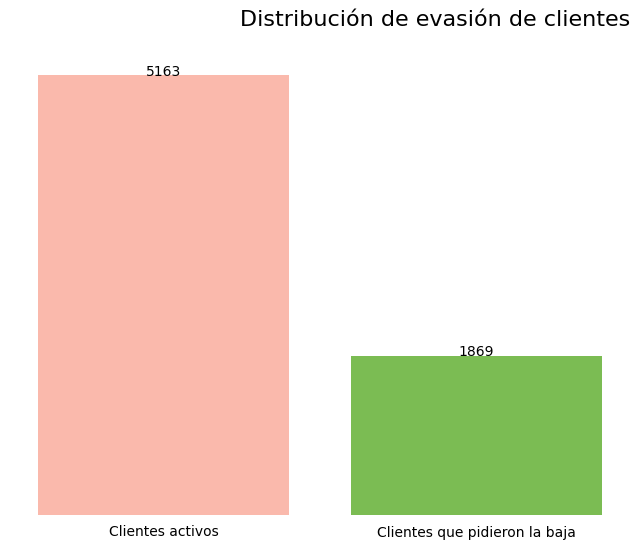

In [42]:
# realizamos un gráfico de barras tomando los porcentajes
categorias = ['Clientes activos', 'Clientes que pidieron la baja']
cantidades = [distribucion_evasion[0], distribucion_evasion[1]]

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(categorias, cantidades, color=colores)

ax.set_title('Distribución de evasión de clientes', loc='right', fontsize=16, pad=20)
ax.set_xlabel('')
ax.set_ylabel('')

for i, valor in enumerate(cantidades):
    ax.text(i, valor + 1, f'{valor}', ha='center')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(left=False,bottom=False)
plt.yticks([])

plt.show()


## Análisis de las variables

Primer análisis:
* Columna Churn / Evasión
* Columna Gender / Género
* Columna Senior Citizen / Adulto Mayor

Se busca saber la proporción de clientes que dejan la empresa en base a su género (Hombre/Mujer) y si son adultos mayores (+65 años) o no.



In [43]:
genero_edad = datos.groupby(['Gender', 'Senior Citizen'])['Churn'].value_counts().unstack()

hombre_mayor = genero_edad.loc[0, 1][1]
hombre_menor = genero_edad.loc[0, 0][1]
mujer_mayor = genero_edad.loc[1, 1][1]
mujer_menor = genero_edad.loc[1, 0][1]

mayores = hombre_mayor + mujer_mayor
menores = hombre_menor + mujer_menor

hombres = hombre_mayor + hombre_menor
mujeres = mujer_mayor + mujer_menor

print(f'''Cantidad de clientes que se han dado de baja:

Hombre y mayor a 65 años: {hombre_mayor}
Hombre y menor a 65 años: {hombre_menor}
Total de hombres que se han dado de baja: {hombres}

Mujer y mayor a 65 años: {mujer_mayor}
Mujer y menor a 65 años: {mujer_menor}
Total de mujeres que se han dado de baja: {mujeres}

Clientes mayores a 65 años: {mayores}
Clientes menores a 65 años: {menores}''')

Cantidad de clientes que se han dado de baja:

Hombre y mayor a 65 años: 236
Hombre y menor a 65 años: 694
Total de hombres que se han dado de baja: 930

Mujer y mayor a 65 años: 240
Mujer y menor a 65 años: 699
Total de mujeres que se han dado de baja: 939

Clientes mayores a 65 años: 476
Clientes menores a 65 años: 1393


Segundo análisis:
* Columna Churn / Evasión
* Columna Partner / Pareja
* Columna Dependents / Dependientes o Adicionales

Se busca saber la proporción de clientes que tengan o no pareja y si cuentan con adicionales o no a su servicio.



In [44]:
partner_dependents = datos.groupby(['Partner', 'Dependents'])['Churn'].value_counts().unstack()

sipareja_sidependientes = partner_dependents.loc[1,1][1]
nopareja_nodependientes = partner_dependents.loc[0,0][1]
sipareja_nodependientes = partner_dependents.loc[1,0][1]
nopareja_sidependientes = partner_dependents.loc[0,1][1]

print(f'''Cantidad de clientes que se han dado de baja:

Con pareja y con dependientes: {sipareja_sidependientes}
Con pareja pero sin dependientes: {sipareja_nodependientes}

Sin pareja y sin dependientes: {nopareja_nodependientes}
Sin pareja pero con dependientes: {nopareja_sidependientes}''')

Cantidad de clientes que se han dado de baja:

Con pareja y con dependientes: 249
Con pareja pero sin dependientes: 420

Sin pareja y sin dependientes: 1123
Sin pareja pero con dependientes: 77


Tercer análisis:
* Columna Churn / Evasión
* Columna Tenure / Tenencia
* Columna Contract / Contrato

Se busca saber la proporción de clientes que dejan la empresa en base a los años que llevan en la empresa y el tipo de contrato que tienen (Mensual/Anual/Bianual)



In [45]:
tenencia = datos.groupby('Churn')['Tenure'].value_counts().unstack()

# agrupados cada 12 meses. total = 6 años
primero = (tenencia.iloc[1,:12]).sum()
segundo = (tenencia.iloc[1,12:24]).sum()
tercero = (tenencia.iloc[1,24:36]).sum()
cuarto = (tenencia.iloc[1,36:48]).sum()
quinto = (tenencia.iloc[1,48:60]).sum()
sexto = (tenencia.iloc[1,60:]).sum()

print(f'''Cantidad de clientes que se han dado de baja:

Primer año: {primero}
Segundo año: {segundo}
Tercer año: {tercero}
Cuarto año: {cuarto}
Quinto año: {quinto}
Sexto año: {sexto}''')

Cantidad de clientes que se han dado de baja:

Primer año: 1037
Segundo año: 294
Tercer año: 180
Cuarto año: 145
Quinto año: 120
Sexto año: 93


In [46]:
tipo_contrato = datos.groupby('Contract')['Churn'].value_counts().unstack()

contrato_mensual = tipo_contrato.loc["Month-to-month"][1]
contrato_anual = tipo_contrato.loc["One year"][1]
contrato_bianual = tipo_contrato.loc["Two year"][1]

contrato_df = pd.DataFrame({
    'Contrato' : ['Mensual', 'Anual', 'Bianual'],
    'N° clientes' : [contrato_mensual, contrato_anual, contrato_bianual]
})

print(contrato_df)

  Contrato  N° clientes
0  Mensual         1655
1    Anual          166
2  Bianual           48


In [47]:
df_contrato = datos.copy()
df_contrato = datos[['Churn','Tenure','Contract']]

# agrupo los datos de la columna Ternure por años
subconjunto1 = list(range(1, 13))
subconjunto2 = list(range(13, 25))
subconjunto3 = list(range(25, 37))
subconjunto4 = list(range(37, 49))
subconjunto5 = list(range(49, 61))
subconjunto6 = list(range(61, 73))

# contadores para sumar tipo de contrato
uno_mensual = 0
uno_anual = 0
uno_bianual = 0

dos_mensual = 0
dos_anual = 0
dos_bianual = 0

tres_mensual = 0
tres_anual = 0
tres_bianual = 0

cuatro_mensual = 0
cuatro_anual = 0
cuatro_bianual = 0

cinco_mensual = 0
cinco_anual = 0
cinco_bianual = 0

seis_mensual = 0
seis_anual = 0
seis_bianual = 0

# bucle for para obtener los datos
for index, row in df_contrato.iterrows():
  if row['Churn'] == 1 and row['Tenure'] in subconjunto1: # primer año
    if row['Contract'] == 'Month-to-month':
      uno_mensual += 1
    elif row['Contract'] == 'One year':
      uno_anual += 1
    elif row['Contract'] == 'Two year':
      uno_bianual += 1
  elif row['Churn'] == 1 and row['Tenure'] in subconjunto2: # segundo año
    if row['Contract'] == 'Month-to-month':
      dos_mensual += 1
    elif row['Contract'] == 'One year':
      dos_anual += 1
    elif row['Contract'] == 'Two year':
      dos_bianual += 1
  elif row['Churn'] == 1 and row['Tenure'] in subconjunto3: # tercer año
    if row['Contract'] == 'Month-to-month':
      tres_mensual += 1
    elif row['Contract'] == 'One year':
      tres_anual += 1
    elif row['Contract'] == 'Two year':
      tres_bianual += 1
  elif row['Churn'] == 1 and row['Tenure'] in subconjunto4: # cuarto año
    if row['Contract'] == 'Month-to-month':
      cuatro_mensual += 1
    elif row['Contract'] == 'One year':
      cuatro_anual += 1
    elif row['Contract'] == 'Two year':
      cuatro_bianual += 1
  elif row['Churn'] == 1 and row['Tenure'] in subconjunto5: # quinto año
    if row['Contract'] == 'Month-to-month':
      cinco_mensual += 1
    elif row['Contract'] == 'One year':
      cinco_anual += 1
    elif row['Contract'] == 'Two year':
      cinco_bianual += 1
  elif row['Churn'] == 1 and row['Tenure'] in subconjunto6: # sexto año
    if row['Contract'] == 'Month-to-month':
      seis_mensual += 1
    elif row['Contract'] == 'One year':
      seis_anual += 1
    elif row['Contract'] == 'Two year':
      seis_bianual += 1

contrato_tenure = pd.DataFrame({
    'Año': ['1er año', '2do año', '3er año', '4to año', '5to año', '6to año'],
    'Mensual': [uno_mensual, dos_mensual, tres_mensual, cuatro_mensual, cinco_mensual, seis_mensual],
    'Anual': [uno_anual, dos_anual, tres_anual, cuatro_anual, cinco_anual, seis_anual],
    'Bianual': [uno_bianual, dos_bianual, tres_bianual, cuatro_bianual, cinco_bianual, seis_bianual]
})

print(contrato_tenure)

       Año  Mensual  Anual  Bianual
0  1er año     1024     13        0
1  2do año      278     16        0
2  3er año      158     20        2
3  4to año      106     35        4
4  5to año       65     44       11
5  6to año       24     38       31


Cuarto análisis:
* Columna Churn / Evasión
* Columna Phone Service / Servicio Telefónico
* Columna Internet Service / Servicio de Internet

Se busca saber la proporción de clientes que dejan la empresa que hayan contratado el servicio telefónico o el servicio de internet o ambos.



In [48]:
df_contrato = datos.copy()
df_contrato = datos[['Churn','Phone Service','Internet Service']]

# contadores para sumar tipo de servicio
servicio_tel = 0
servicio_int = 0
servicio_tel_int = 0

for index, row in df_contrato.iterrows():
  if row['Churn'] == 1 and row['Phone Service'] == 1 and row['Internet Service'] == 0:
    servicio_tel += 1
  elif row['Churn'] == 1 and row['Phone Service'] == 0 and row['Internet Service'] == 1:
    servicio_int += 1
  elif row['Churn'] == 1 and row['Phone Service'] == 1 and row['Internet Service'] == 1:
    servicio_tel_int += 1

porcentaje_tel = round((servicio_tel / distribucion_evasion[1]) * 100, 1)
porcentaje_int = round((servicio_int / distribucion_evasion[1]) * 100, 1)
porcentaje_tel_int = round((servicio_tel_int / distribucion_evasion[1]) * 100, 1)

servicios = pd.DataFrame({
          'Servicio': ['Telefónico', 'Internet', 'Ambos'],
          'Clientes': [servicio_tel, servicio_int, servicio_tel_int],
          'Porcentaje': [porcentaje_tel, porcentaje_int, porcentaje_tel_int]
})

print(servicios)

     Servicio  Clientes  Porcentaje
0  Telefónico       113         6.0
1    Internet       170         9.1
2       Ambos      1586        84.9


Quinto análisis:
* Columna Churn / Evasión
* Columna Charges Monthly / Cargos Mensuales
* Columna Charges Total / Cargos Totales

Se busca una comparación entre los gastos mensuales y totales entre los clientes que deciden permanecer vs los clientes que dejan la empresa.



In [49]:
df_cargos = datos[['Churn','Charges Monthly','Charges Total']]

# clientes activos
cargos_activos = df_cargos[df_cargos['Churn'] == 0]
activos_df = cargos_activos.describe(percentiles=[0.5])
activos_df = pd.DataFrame(activos_df)
activos_df = activos_df.drop(columns='Churn', axis=1)

# clientes que se fueron
cargos_inactivos = df_cargos[df_cargos['Churn'] == 1]
inactivos_df = cargos_inactivos.describe(percentiles=[0.5])
inactivos_df = pd.DataFrame(inactivos_df)
inactivos_df = inactivos_df.drop(columns='Churn', axis=1)

# cambiar los nombres de las columnas para una interpretación mas legible
activos_df['Mensual | Activos'] = activos_df['Charges Monthly']
activos_df['Total | Activos'] = activos_df['Charges Total']

inactivos_df['Mensual | Inactivos'] = inactivos_df['Charges Monthly']
inactivos_df['Total | Inactivos'] = inactivos_df['Charges Total']

# creación de las tablas de comparación
mensuales = pd.concat([activos_df['Mensual | Activos'], inactivos_df['Mensual | Inactivos']], axis=1)
totales = pd.concat([activos_df['Total | Activos'], inactivos_df['Total | Inactivos']], axis=1)

In [50]:
print(mensuales)

       Mensual | Activos  Mensual | Inactivos
count        5163.000000          1869.000000
mean           61.307408            74.441332
std            31.094557            24.666053
min            18.250000            18.850000
50%            64.450000            79.650000
max           118.750000           118.350000


In [53]:
dif_mensual = round(((74.44 - 61.31) / 74.44) * 100, 1)
dif_mensual

17.6

In [54]:
print(totales)

       Total | Activos  Total | Inactivos
count      5163.000000        1869.000000
mean       2555.344141        1531.796094
std        2329.456984        1890.822994
min          18.800000          18.850000
50%        1683.600000         703.550000
max        8672.450000        8684.800000


In [55]:
dif_total = round(((2555.34 - 1531.8) / 2555.34) * 100, 1)
dif_total

40.1

Sexto análisis:
* Columna Churn / Evasión
* Columna Payment Method / Método de pago

Se busca una comparación de los métodos de pago elegidos entre los clientes que deciden permanecer vs los clientes que dejan la empresa.



In [56]:
df_metodo_pago = datos[['Churn','Payment Method']]

#clientes activos
metodo_activos = df_metodo_pago[df_metodo_pago['Churn'] == 0]
metodo_activos = metodo_activos['Payment Method'].value_counts()

transf_act = metodo_activos.loc['Bank transfer (automatic)']
tarj_act = metodo_activos.loc['Credit card (automatic)']
celec_act = metodo_activos.loc['Electronic check']
ccorr_act = metodo_activos.loc['Mailed check']

#clientes inactivos
metodo_inactivos = df_metodo_pago[df_metodo_pago['Churn'] == 1]
metodo_inactivos = metodo_inactivos['Payment Method'].value_counts()

transf_inact = metodo_inactivos.loc['Bank transfer (automatic)']
tarj_inact = metodo_inactivos.loc['Credit card (automatic)']
celec_inact = metodo_inactivos.loc['Electronic check']
ccorr_inact = metodo_inactivos.loc['Mailed check']

porcentaje_transf_inact = round((transf_inact / distribucion_evasion[1]) * 100, 1)
porcentaje_tarj_inact = round((tarj_inact / distribucion_evasion[1]) * 100, 1)
porcentaje_celec_inact = round((celec_inact / distribucion_evasion[1]) * 100, 1)
porcentaje_ccorr_inact = round((ccorr_inact / distribucion_evasion[1]) * 100, 1)

metodo_pago = pd.DataFrame({
    'Método' : ['Transf. bancaria', 'Tarjeta Crédito', 'Cheque electrónico', 'Cheque por correo'],
    'Activos' : [transf_act, tarj_act, celec_act, ccorr_act],
    'Inactivos' : [transf_inact, tarj_inact, celec_inact, ccorr_inact],
    '% Inactivos' : [porcentaje_transf_inact, porcentaje_tarj_inact, porcentaje_celec_inact, porcentaje_ccorr_inact]
})

print(metodo_pago)

               Método  Activos  Inactivos  % Inactivos
0    Transf. bancaria     1284        258         13.8
1     Tarjeta Crédito     1289        232         12.4
2  Cheque electrónico     1294       1071         57.3
3   Cheque por correo     1296        308         16.5


#📄 Informe final

## Introducción

La empresa Telecom X está enfrentando una alta tasa de cancelaciones entre sus clientes. Este informe final tiene como objetivo poder comprender cuáles son los posibles factores que llevan a la pérdida de clientes, con el fin de poder desarrollar estrategias para reducir la evasión.

## Limpieza y Tratamiento de Datos

Tras la importación y la carga de datos, se realizó una normalización —convertir estructuras de datos anidadas en un formato tabular de filas y columnas— con el archivo JSON proporcionado. En este caso, se almacenó cada columna en un dataframe distinto para así poder concatenarlas.

Luego, se exploró el dataframe  y se analizó los tipos de datos de cada columna. Durante la comprobación de incoherencias, se buscó encontrar:

- Cuáles eran los valores únicos de cada categoría.
- Si existían valores duplicados.
- Sí existían valores nulos.
- Si existían valores vacios o en blanco.
- Errores e inconsistencias en las categorías donde se realizó un saneamiento de algún tipo de valor nulo y/o vacío, pasaje de un tipo de dato.

Como actividades opcionales, se creo una columna de cuentas diarias a partir de la columna Charges Monthly.

Además, se estandarizaron y transformaron los datos.

- Aquellas columnas que contenían 2 valores únicos, "Yes" y "No", se transformaron a 1 y 0, respectivamente.
- Aquellas columnas que contenían 3 valores únicos, primero se transformaron los datos para que queden solo dos categorías, "Yes" y "No". Luego, se transformaron a 1 y 0, respectivamente.
- La columna Género, "Male" obtuvo el valor 0 Y "Female", 1.

Para finalizar esta etapa, se unificó el criterio para todos los nombres de las columnas.




## Análisis Exploratorio de Datos

### Fuga de clientes

De los 7043 clientes que fueron analizados, 1869  decidieron irse de baja del servicio. Aunque la empresa aun retiene el 73,46% de su cartera, ha perdido un 26,54% de su clientela.

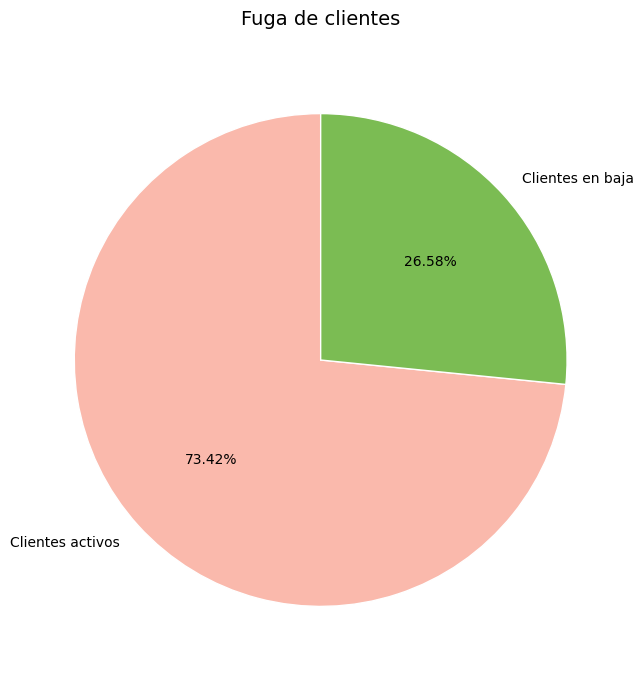

In [70]:
valores = [cliente_permanencia, cliente_baja]
labels = ['Clientes activos', 'Clientes en baja']

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    valores,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,
    colors=colores,
    wedgeprops={'edgecolor': 'white'}
)

ax.set_title(
    'Fuga de clientes',
    fontsize=14,
    pad=20
)

plt.show()

### Perfil del cliente

Se analizó las características del cliente en base a, por un lado, género y edad y, por el otro, estado civil y dependientes/adicionales.

* *Variables género y edad*

En primera instancia, se tomaron las variables género y edad y se las analizó por separado y en conjunto.

Como se puede visualizar en el gráfico nro. 1, variable sexo, no podemos decir que haya una inclinación de un lado u otro.

Sin embargo, el principal dato relevante queda reflejado en el gráfico nro. 2, con la variable edad, donde la mayoría de los clientes que se marcharon eran menores a 65 años, en contraposición a los mayores de 65.

Con el desflose de los datos en el gráfico nro. 3, podemos ver claramente lo mencionado más arriba: *no hay diferencia entre mujeres y hombres, pero si una marcada decisión por parte de aquellos no considerados adultos mayores en irse de la empresa.*



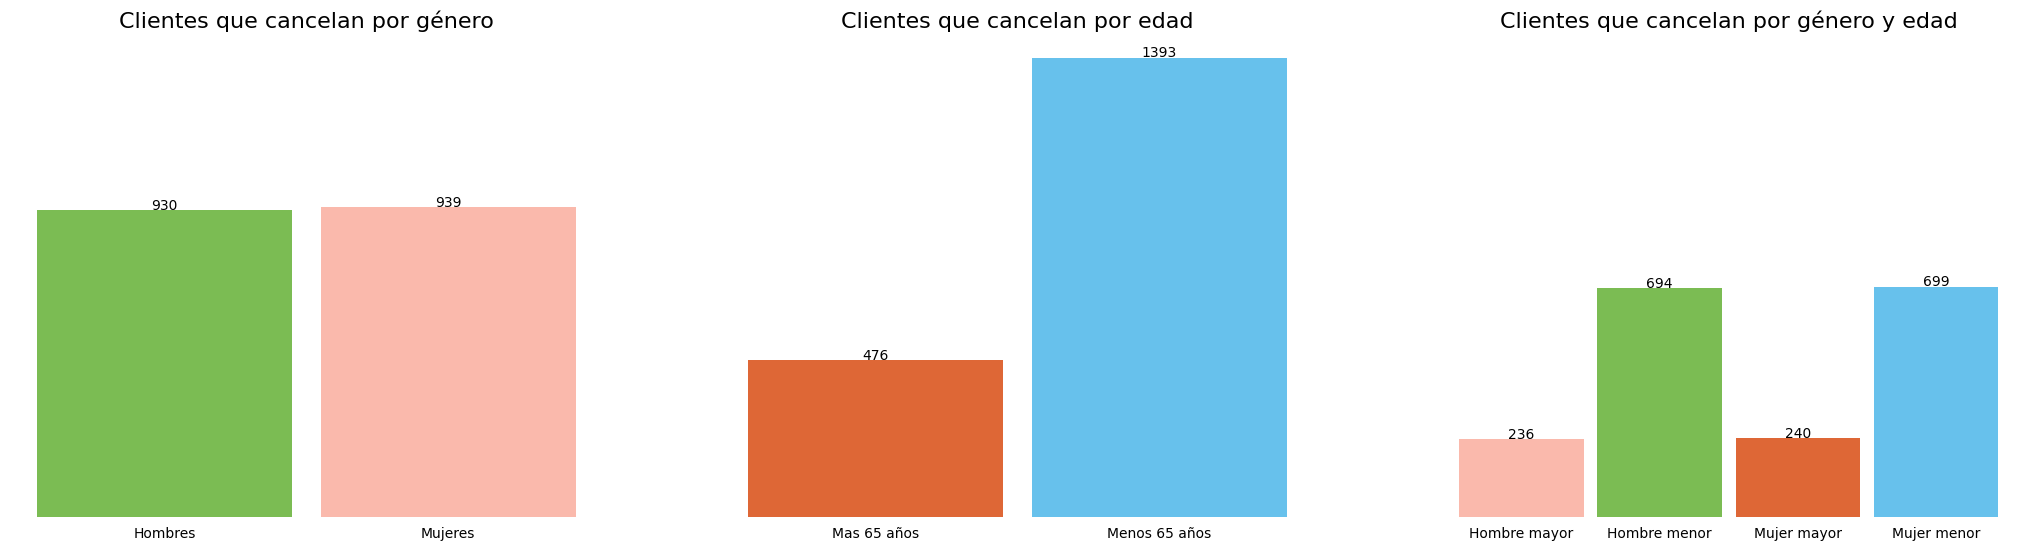

In [71]:
# realizamos un gráfico de barras
fig, axs = plt.subplots(1,3,figsize=(26, 6))

# primer gráfico SEXO
categoriasaxs0 = ['Hombres', 'Mujeres']
cantidadesaxs0 = [hombre_mayor + hombre_menor, mujer_mayor + mujer_menor]

axs[0].bar(categoriasaxs0, cantidadesaxs0, color=['#7BBC53FF','#FAB9ACFF'], width=0.9)
axs[0].set_title('Clientes que cancelan por género', loc='center', fontsize=16, pad=20)

for i, valor in enumerate(cantidadesaxs0):
    axs[0].text(i, valor + 1, f'{valor}', ha='center')

axs[0].set_ylim(0, 1400)

# segundo gráfico EDAD
categoriasaxs1 = ['Mas 65 años', 'Menos 65 años']
cantidadesaxs1 = [mayores, menores]

axs[1].bar(categoriasaxs1, cantidadesaxs1, color=['#DE6736FF','#67C1ECFF'], width=0.9)
axs[1].set_title('Clientes que cancelan por edad', loc='center', fontsize=16, pad=20)

for i, valor in enumerate(cantidadesaxs1):
    axs[1].text(i, valor + 1, f'{valor}', ha='center')

axs[1].set_ylim(0, 1400)

for a in axs.flat:
    a.spines[['top', 'right', 'left','bottom']].set_visible(False)
    a.get_yaxis().set_visible(False)
    a.tick_params(left=False,bottom=False)

# tercer grafico SEXO Y EDAD
categoriasaxs2 = ['Hombre mayor', 'Hombre menor', 'Mujer mayor', 'Mujer menor']
cantidadesaxs2 = [hombre_mayor, hombre_menor, mujer_mayor, mujer_menor]

axs[2].bar(categoriasaxs2, cantidadesaxs2, color=colores, width=0.9)
axs[2].set_title('Clientes que cancelan por género y edad', loc='center', fontsize=16, pad=20)

for i, valor in enumerate(cantidadesaxs2):
    axs[2].text(i, valor + 1, f'{valor}', ha='center')

axs[2].set_ylim(0, 1400)


plt.show()

* *Variables pareja y dependientes*

Se buscó saber si el cliente tenia o no pareja y/o dependientes/adicionales.

El gráfico de barras horizontal muestra claramente que, por un amplio margen, el cliente soltero y sin adicionales es el que mayor tendencia tiene en irse. Le siguen cliente con pareja sin adicionales, con pareja y dependientes y, por último,  sin pareja pero con adicionales.

Se puede inferir, entonces, que aquellos que no tienen dependientes o adicionales son los principales en irse. Una posible hipótesis podría ser que los adicionales sean menores de edad que obtienen la línea a través del titular, por lo que es más difícil que el cliente se marche cuando otro depende directamente de ellos y no haya posibilidad de acceder de forma independiente.

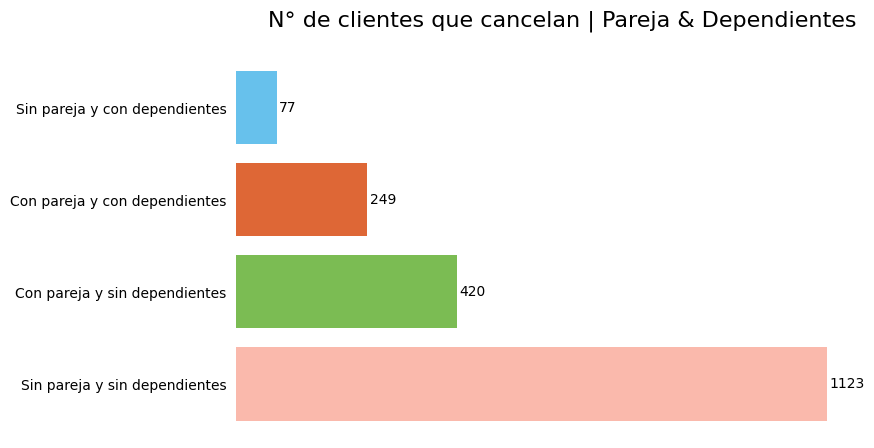

In [74]:
churn_pareja_dependientes = pd.Series({
    'Con pareja y con dependientes': sipareja_sidependientes,
    'Con pareja y sin dependientes': sipareja_nodependientes,
    'Sin pareja y con dependientes': nopareja_sidependientes,
    'Sin pareja y sin dependientes': nopareja_nodependientes})

churn_pareja_dependientes = churn_pareja_dependientes.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    churn_pareja_dependientes.index,
    churn_pareja_dependientes.values,
    color=colores)

ax.set_title('N° de clientes que cancelan | Pareja & Dependientes', loc='right', fontsize=16, pad=20)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.tick_params(left=False)

for i, valor in enumerate(churn_pareja_dependientes.values):
    ax.text(valor + 5, i, str(valor), va='center')

for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

### Preferencias del cliente

Ahora se analizan las preferencias del cliente con respecto al servicio ofrecido.

* *Variables tipo de contrato y tenencia*

Se buscó saber que tipo de contrato tiene aquellos clientes que deciden marcharse. 88,55% corresponde a contratos mensuales, siguiendoles por los anuales (8,88%) y bianuales (2,57%), como se muestra en el gráfico de torta.

Esta clara preferencia por encima de las otras dos podría estar relacionada a la libertad que ofrece el contrato mes a mes, en contraposición de uno anual o bianual.

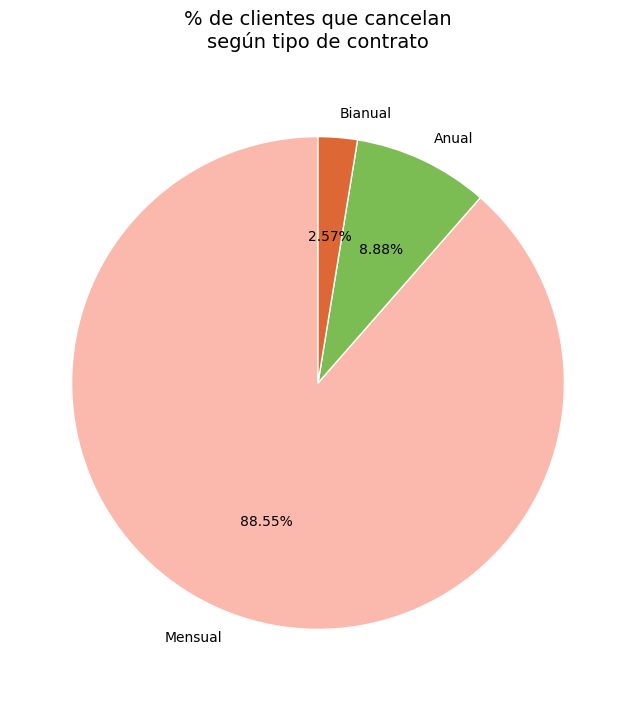

In [76]:
valores = contrato_df['N° clientes']
labels = contrato_df['Contrato']

def formato(pct):
    total = sum(valores)
    cantidad = int(round(pct * total / 100))
    return f'{pct:.2f}%'

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    valores,
    labels=labels,
    autopct=formato,
    startangle=90,
    colors=colores,
    wedgeprops={'edgecolor': 'white'}
)

ax.set_title(
    '% de clientes que cancelan\nsegún tipo de contrato',
    fontsize=14,
    pad=20
)

plt.show()

Se cruzaron los datos de Tipo de contrato (Mensual - Anual - Bianual) por los meses contratados. Se puede observar una menor tasa de adhesión al tipo de contrato bianual con respecto a los otros dos, siendo el contrato mensual el que ocupa el primer puesto.

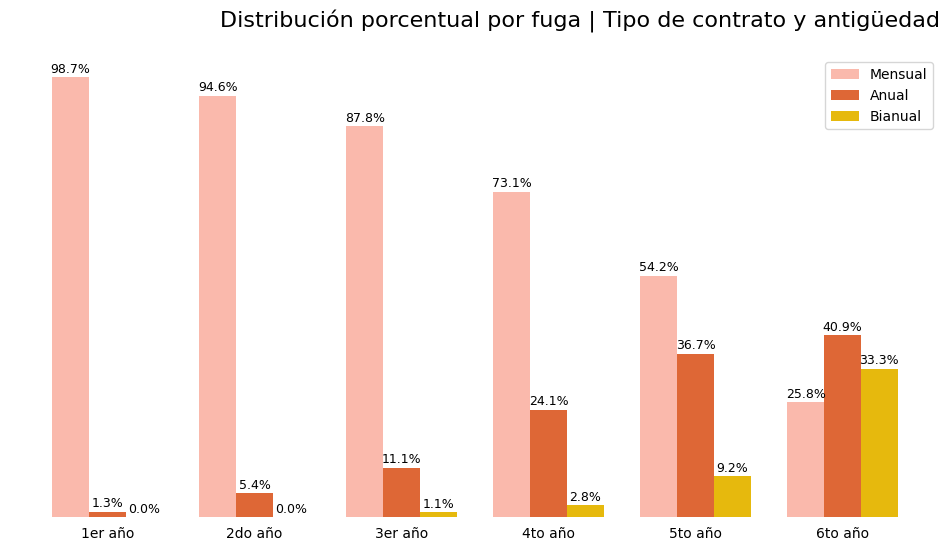

In [78]:
contrato_tenure[['Mensual', 'Anual', 'Bianual']] = (
    contrato_tenure[['Mensual', 'Anual', 'Bianual']]
    .div(contrato_tenure[['Mensual', 'Anual', 'Bianual']].sum(axis=1), axis=0) * 100
)

x = np.arange(len(contrato_tenure['Año']))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width, contrato_tenure['Mensual'], width, label='Mensual', color='#FAB9ACFF')
ax.bar(x, contrato_tenure['Anual'], width, label='Anual', color='#DE6736FF')
ax.bar(x + width, contrato_tenure['Bianual'], width, label='Bianual', color='#E6B90DFF')

ax.set_title('Distribución porcentual por fuga | Tipo de contrato y antigüedad',loc='right',fontsize=16,pad=20)
ax.set_xticks(x)
ax.set_xticklabels(contrato_tenure['Año'])
ax.legend()

for i in range(len(x)):
    ax.text(x[i] - width, contrato_tenure['Mensual'][i] + 1, f"{contrato_tenure['Mensual'][i]:.1f}%", ha='center', fontsize=9)
    ax.text(x[i], contrato_tenure['Anual'][i] + 1, f"{contrato_tenure['Anual'][i]:.1f}%", ha='center', fontsize=9)
    ax.text(x[i] + width, contrato_tenure['Bianual'][i] + 1, f"{contrato_tenure['Bianual'][i]:.1f}%", ha='center', fontsize=9)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(left=False, bottom=False)
plt.yticks([])

plt.show()


* *Variables servicios, telefónico e internet*

Acá se exploró saber cuales son los servicios preferidos por parte del cliente. En este gráfico de barras horizontal, se expresa claramente la preferencia a contratar a ambos servicios (84,90%), el telefónico y el de internet, por encima de contratar por separado.

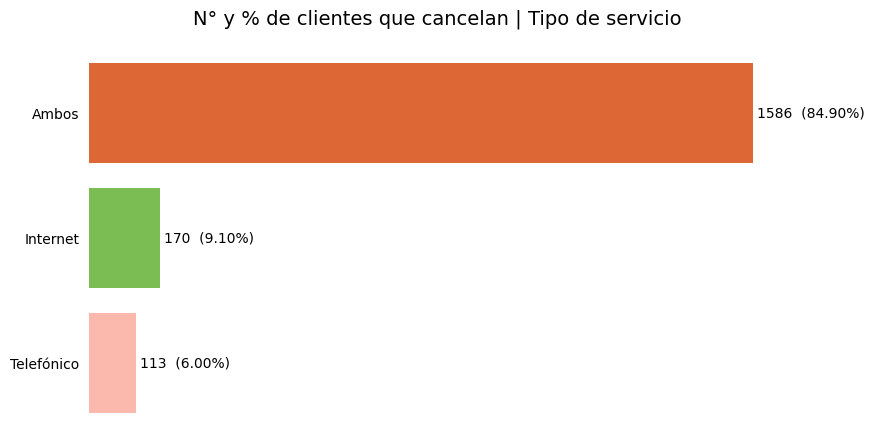

In [87]:
labels = servicios['Servicio']
porcentajes = servicios['Porcentaje']
cantidades = servicios['Clientes']

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.barh(labels, porcentajes, color=colores)

ax.set_title(
    'N° y % de clientes que cancelan | Tipo de servicio',
    fontsize=14,
    pad=15
)

for i, (cant, pct) in enumerate(zip(cantidades, porcentajes)):
    ax.text(
        pct + 0.5,
        i,
        f'{cant}  ({pct:.2f}%)',
        va='center'
    )

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(left=False, bottom=False)
plt.xticks([])

ax.grid(visible=False)

plt.show()

* *Variables pago mensual y pago total*

A través de los gráficos de boxplot, se puede evidenciar que los clientes que cancelan presentan una mediana de gasto mensual superior a la de los clientes activos. En contraposición, la mediana del gasto total es menor, debido a que los clientes activos tienen totales más alto debido a una mayor antigüedad.

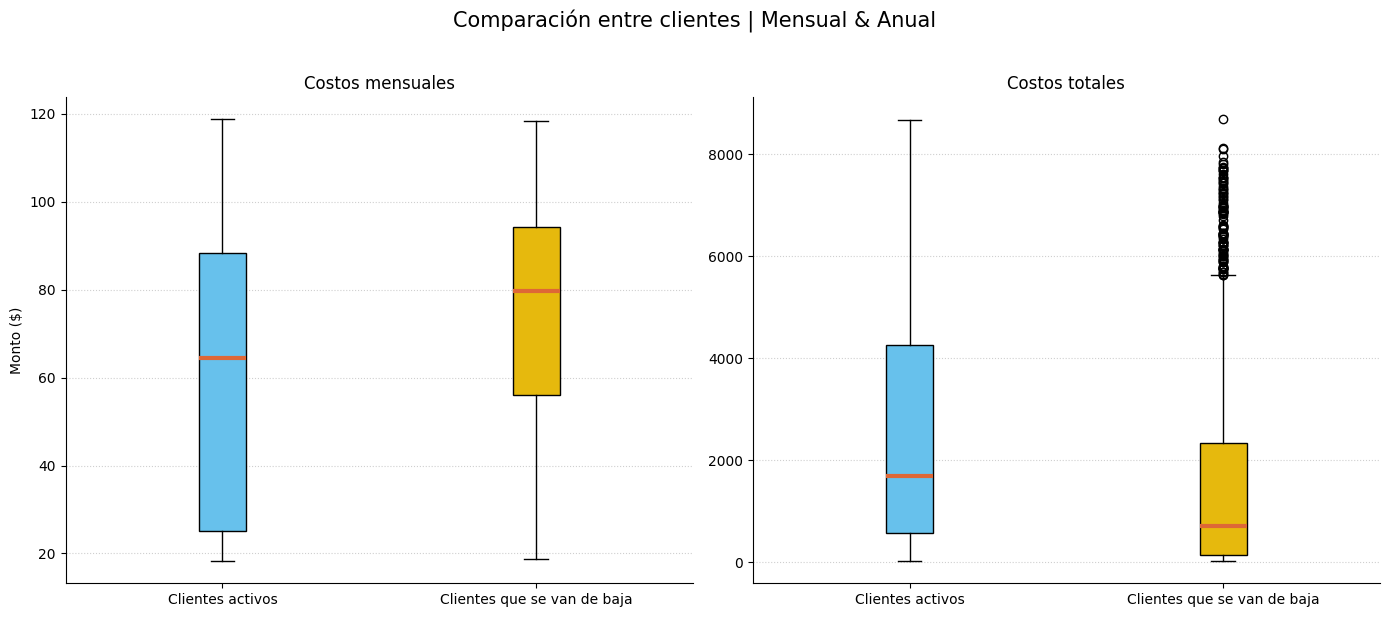

In [ ]:
activos_m = df_cargos[df_cargos['Churn'] == 0]['Charges Monthly']
inactivos_m = df_cargos[df_cargos['Churn'] == 1]['Charges Monthly']
activos_t = df_cargos[df_cargos['Churn'] == 0]['Charges Total']
inactivos_t = df_cargos[df_cargos['Churn'] == 1]['Charges Total']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colores = ['#67C1ECFF', '#E6B90DFF']  # Activos | Inactivos

# Charges Monthly
box1 = axes[0].boxplot(
    [activos_m, inactivos_m],
    tick_labels=['Clientes activos', 'Clientes que se van de baja'],
    patch_artist=True
)

for patch, color in zip(box1['boxes'], colores):
    patch.set_facecolor(color)

for median in box1['medians']:
    median.set_color('#DE6736FF')
    median.set_linewidth(3)

axes[0].set_title('Costos mensuales')
axes[0].set_ylabel('Monto ($)')
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Charges Total
box2 = axes[1].boxplot(
    [activos_t, inactivos_t],
    tick_labels=['Clientes activos', 'Clientes que se van de baja'],
    patch_artist=True
)

for patch, color in zip(box2['boxes'], colores):
    patch.set_facecolor(color)

for median in box2['medians']:
    median.set_color('#DE6736FF')
    median.set_linewidth(3)

axes[1].set_title('Costos totales')
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Comparación entre clientes | Mensual & Anual', fontsize=15, y=1.02)

plt.tight_layout()
plt.show()

* *Variable método de pago*

Según el método de pago seleccionado, más de la mitad de los clientes fugados preferían el cheque electrónico (57,3%) sobre cheque por correo (16,48%), transferencia bancaria (13,8%) y tarjeta de crédito (12,41%). En tanto que los clientes que aun siguen activos, no hay grandes variaciones entre un método y otro, siendo el preferido el cheque por correo.

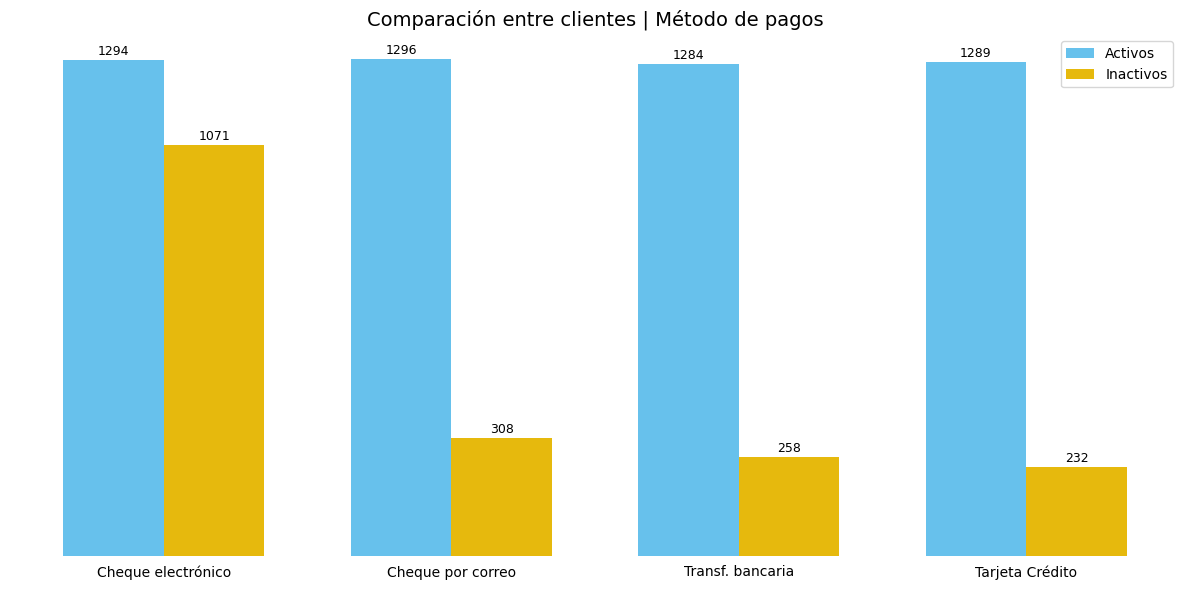

In [ ]:
labels = metodo_pago['Método']
activos = metodo_pago['Activos']
inactivos = metodo_pago['Inactivos']

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, activos, width, label='Activos', color=colores[0])
bars2 = ax.bar(x + width/2, inactivos, width, label='Inactivos', color=colores[1])

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 5,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 5,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=9)

ax.set_title('Comparación entre clientes | Método de pagos', fontsize=14)
ax.set_xticks(x)
ax.tick_params(left=False,bottom=False)
ax.set_yticklabels([])
ax.set_xticklabels(labels)
ax.legend()

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## Conclusiones e Insights

Tras el análisis exploratorio de los datos, se concluyó que:

Según su perfil, la mayoría de los cientes que deciden darse de baja de los servicios de la empresa son aquellos menores a 65 años que no tienen pareja ni dependientes. Probablemente tengan menor "costo de cambio" y menos barreras emocionales para irse.

Según las preferencias del cliente en cuanto al servicio, podemos ver que la mayor parte de las bajas se concentran en el primer año de servicio. Por ende, es entendible que el cliente prefiera un contrato mensual por encima del anual o bianual.

Sin embargo, aún cuando ya se probó el servicio, el cliente no muestra interés en cambiar de tipo de contrato en el corto plazo, prefiriendo pagar mes a mes. Como se muestra en el gráfico de "Distribución porcentual de evasión por tipo de contrato y antigüedad", recién en el sexto año, tanto el contrato anual como el bianual, superan al mensual.

En cuanto a los servicios prestados, el 84,9% de los clientes habían adquirido ambos servicios, el telefónico y el de internet. Le sigue solo internet con 9,1% y solo telefónico, con 6%.

En el comparativo de Gastos Totales, el promedio de los cientes que decidieron irse es mucho menor que los últimos, un 40,1% menos, y la desviación estándar es alta (1890.8 vs 2329.5). Sin embargo, esta tendencia no se representa en los Gastos Mensuales, donde el promedio de gasto es mucho mayor mes a mes para los clientes inactivos en comparación a los activos, un 17,6% más.

Por último, la distribución de los métodos de pago en los clientes activos no varía tanto como los viejos clientes. Se demostró que aquellos cuyo método de pago es cheque electrónico, componen el 57% de la masa de clientes.  

## Recomendaciones

### Según perfil del cliente

El mayor grupo de fuga son menores de 65 años, sin pareja ni dependientes. Al no haber terceros, la decisión de cancelar el servicio es individual y no está condicionada, por lo que se necesita generar incentivos que aumenten el valor percibido y fortalecer el vínculo con la empresa.

* Diseñar planes optimizados a las necesidades del cliente individual.
* Ofrecer beneficios atractivos, como programas de fidelización temprana (puntos, descuentos progresivos) o alianzas con terceros (streaming, gaming, experiencias).

### Según preferencias del cliente con respecto al servicio

La mayor concentración de bajas se registran durante el primer año de servicio, especialmente en contratos mensuales.

* Realizar encuestas de satisfacción para detectar fricciones antes que el cliente decida cancelar.
* Desarrollar alertas predictivas considerando baja de consumo y/o reiteradas muestras de insatisfacción por canales oficiales.
* Ofrecer incentivos para pasar a contrato anual o bianuales antes del mes 12 con una bonificación por pago adelantado.
* En caso de desear mantener el contrato mensual, ofrecer beneficios acumulativos por permanencia, como descuento escalonado automático.

Se observa que el análisis de los gastos mensuales de los clientes que cancelan sugiere una posible sensibilidad al precio o una percepción insuficiente de valor en relación con el costo.

* Analizar si los planes con mayor tarifa mensual generan mayor insatisfacción.
* Implementar ofertas personalizadas, como bajar a un plan más económico automáticamente.
* Ofrecer descuentos reales por combo de servicios, al observarse que un 84,9% contrata los dos.

En cuanto al método de pago, el cheque electrónico es el método predominante de los clientes que se dan de baja. Podría existir descontento asociadas a este sistema o poco incentivo a escoger a otros métodos.

* Ofrecer bonificación por adherirse a medios de pagos automáticos.
* Revisar el proceso de pago del cheque electrónico con respecto a otros medios, ante la posibilidad de insatisfacción del cliente con el servicio.

### Recomendación estratégica general

Se le recomienda a la empresa implementar un modelo de scoring de riesgo de fuga combinando las siguientes variables, para realizar campañas preventivas:

* Edad
* Estado Civil
* Adicionales
* Tenencia / Antigüedad
* Tipo de contrato
* Gasto mensual previsto
* Método de pago
